In [ ]:
import pandas as pd

ptbxl = pd.read_csv('/media/Volume/data/PTB-XL/ptbxl_database.csv')
ptbxl.head()

,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [ ]:
# plot dist age
import plotly.express as px

fig = px.histogram(ptbxl, x="age", nbins=30, title="Age Distribution")
fig.update_layout(xaxis_title="Age", yaxis_title="Count")

In [11]:
mimic = pd.read_csv('/media/Volume/data/MIMIC_IV/records_w_diag_icd10.csv')
print(mimic.columns)
mimic.head()

Index(['file_name', 'study_id', 'subject_id', 'ecg_time', 'ed_stay_id',
       'ed_hadm_id', 'hosp_hadm_id', 'ed_diag_ed', 'ed_diag_hosp',
       'hosp_diag_hosp', 'all_diag_hosp', 'all_diag_all', 'gender', 'age',
       'anchor_year', 'anchor_age', 'dod', 'ecg_no_within_stay',
       'ecg_taken_in_ed', 'ecg_taken_in_hosp', 'ecg_taken_in_ed_or_hosp',
       'fold', 'strat_fold'],
      dtype='object')


,file_name,study_id,subject_id,ecg_time,ed_stay_id,ed_hadm_id,hosp_hadm_id,ed_diag_ed,ed_diag_hosp,hosp_diag_hosp,...,age,anchor_year,anchor_age,dod,ecg_no_within_stay,ecg_taken_in_ed,ecg_taken_in_hosp,ecg_taken_in_ed_or_hosp,fold,strat_fold
0,mimic-iv-ecg-diagnostic-electrocardiogram-matc...,40689238,10000032,2180-07-23 08:44:00,39399961.0,29079034.0,NaN,"['R4182', 'G9340']","['F319', 'J449', 'B182', 'E871', 'V462', 'I958...",[],...,52.0,2180.0,52.0,2180-09-09,0,True,False,True,17,9
1,mimic-iv-ecg-diagnostic-electrocardiogram-matc...,44458630,10000032,2180-07-23 09:54:00,39399961.0,29079034.0,NaN,"['R4182', 'G9340']","['F319', 'J449', 'B182', 'E871', 'V462', 'I958...",[],...,52.0,2180.0,52.0,2180-09-09,1,True,False,True,17,9
2,mimic-iv-ecg-diagnostic-electrocardiogram-matc...,49036311,10000032,2180-08-06 09:07:00,NaN,NaN,25742920.0,[],[],"['J449', 'B182', 'E871', 'R197', 'V462', 'R188...",...,52.0,2180.0,52.0,2180-09-09,0,False,True,True,17,9
3,mimic-iv-ecg-diagnostic-electrocardiogram-matc...,45090959,10000117,2181-03-04 17:14:00,NaN,NaN,NaN,[],[],[],...,55.0,2174.0,48.0,NaN,-1,False,False,False,18,0
4,mimic-iv-ecg-diagnostic-electrocardiogram-matc...,48446569,10000117,2183-09-18 13:52:00,33176849.0,27988844.0,NaN,"['S72092A', 'W1830XA']","['K219', 'F419', 'Z7901', 'Z87891', 'G43909', ...",[],...,57.0,2174.0,48.0,NaN,0,True,False,True,18,0


In [12]:
fig = px.histogram(mimic, x="age", nbins=30, title="Age Distribution")
fig.update_layout(xaxis_title="Age", yaxis_title="Count")

In [13]:
cpsc = pd.read_csv('/media/Volume/data/CPSC2018/exams_filtered.csv')
cpsc.head()

,Unnamed: 0,file_name,diagnosis_code
0,0,g7/A6001,429622005
1,1,g7/A6002,164884008
2,2,g7/A6003,270492004
3,3,g7/A6004,59118001
4,4,g7/A6005,59118001


In [27]:
import wfdb
from tqdm import tqdm

ages = []
for file in tqdm(cpsc['file_name']):
    path = '/media/Volume/data/CPSC2018/'
    full_path = path + file
    record = wfdb.rdheader(full_path)
    comment = record.__dict__['comments']
    for c in comment:
        if 'age' in c.lower():
            try:
                ages.append(int(c[4:].strip()))
                break
            except ValueError:
                continue


100%|██████████| 6871/6871 [00:05<00:00, 1267.48it/s]


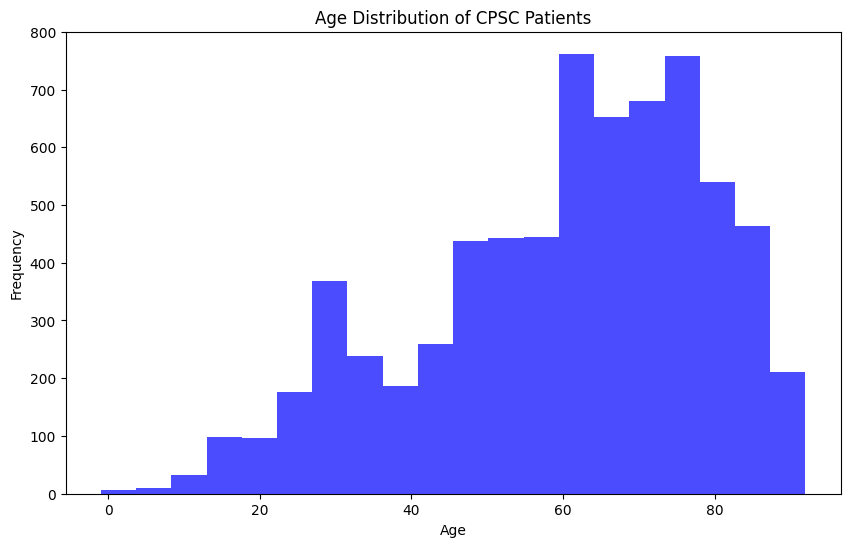

In [29]:
# plot dist of ages cpsc
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.hist(ages, bins=20, color='blue', alpha=0.7)
ax.set_title('Age Distribution of CPSC Patients')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
plt.show()

In [5]:
df_scaled = df_raw.copy()
df_scaled = ((df_raw - df_raw.min()) / (df_raw.max() - df_raw.min()))
#df_scaled = ((df_raw - 0.5) / (df_raw.max()))
df_scaled['LVEF / MAE'] = 1 - df_scaled['LVEF / MAE']
df_scaled.head(n=10)

,PTB-XL / AUC,CPSC2018 / AUC,MIT-BIH / F1,Sleep Apnea / AUC,LVEF / MAE,PPG / AUC,Exercise / F1,R-PEAK / F1
ST-MEM,0.982759,0.721311,0.855856,0.335312,0.000000,0.000000,1.000000,1.000000
ECG-JEPA,0.862069,0.786885,0.518018,0.000000,0.281356,0.643192,1.000000,0.968599
ECG Founder,1.000000,0.901639,0.045045,0.109792,0.728814,0.798122,0.000000,0.000000
ours (transformer),0.948276,0.000000,0.603604,0.344214,0.711864,0.760563,0.936947,0.992754
ours(xlstm),0.931034,1.000000,1.000000,1.000000,1.000000,1.000000,0.984513,0.995169
supervised(xlstm),0.000000,0.377049,0.000000,0.474777,0.406780,0.859155,0.974558,0.972222


In [17]:
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.colors import qualitative
import numpy as np

categories_closed = categories + [categories[0]]

fig = go.Figure()
# Plot one radar chart for each method on separate axes (subplots)

rows = 3
cols = 2

min_v = df_z_scaled.min().min()
max_v = df_z_scaled.max().max()
print(f"Min value: {min_v}, Max value: {max_v}")

num_methods = len(df_z_scaled)
rows = 2
cols = 3
fig = make_subplots(
    rows=rows, cols=cols,
    specs=[[{'type': 'polar'}, {'type': 'polar'}, {'type': 'polar'}],
           [{'type': 'polar'}, {'type': 'polar'}, {'type': 'polar'}]],
    subplot_titles=df_z_scaled.index.tolist(),
    vertical_spacing=.1,  # Add vertical spacing between subplots
    horizontal_spacing=0.15  # Add horizontal spacing between subplots
)

pastel_colors = qualitative.Plotly[:len(df_z_scaled)]
gap = 1.0 / num_methods
padding = 0.06

for i, (idx, row) in enumerate(df_z_scaled.iterrows()):

    current_row = (i // cols) + 1
    current_col = (i % cols) + 1
    #if i == len(df_z_scaled) -1:
    #    continue
    values = row.tolist() + [row.tolist()[0]]  # close the loop
    trace = fig.add_trace(
        go.Scatterpolar(
            r=values,
            theta=categories_closed,
            fill='toself',
            name=idx,
            line=dict(width=3, color=pastel_colors[i]),
            hoverinfo='skip',
        ),
        row=current_row, col=current_col
    )


    # Update polar layout for each subplot
    fig.update_layout({
        f'polar{i+1}': dict(
            angularaxis=dict(rotation=10),  # keep your rotation
            radialaxis=dict(
                visible=True, 
                range=[min_v, max_v], 
                showticklabels=False, 
                showline=False,
                showgrid=True,
            )
        )
    })


# Optional: adjust overall layout for better spacing
fig.update_layout(
    width=18,   # 88mm in pixels (88mm * 2.835 pixels/mm)
    # height=166.3,   # Maintain aspect ratio (2:3 -> height = width * 2/3)
    font=dict(family="Helvetica", size=12),  # Sans-serif font, 6pt (between 5-7pt range)
    showlegend=False,  # Hide legend since each subplot is labeled
    margin=dict(l=50, r=50, t=20, b=20)  # Tight margins for Nature format
)

fig.update_annotations(
    font=dict(size=14, family="Helvetica"),
    showarrow=False,
    #yshift=5,  # Adjust vertical position of titles
)


# save pdf
fig.write_image("radar_chart_methods.pdf")
# fig.show()

Min value: -2.0402112285369545, Max value: 1.7767838508099936


In [7]:
import numpy as np
data_ranked = {
    k: np.argsort(np.argsort(v)[::-1]) for k, v in data.items()
}
data_ranked

{'PTB-XL / AUC': array([1, 4, 0, 2, 3, 5]),
 'CPSC2018 / AUC': array([3, 2, 1, 5, 0, 4]),
 'MIT-BIH / F1': array([1, 3, 4, 2, 0, 5]),
 'Sleep Apnea / AUC': array([3, 5, 4, 2, 0, 1]),
 'LVEF / MAE': array([0, 1, 4, 3, 5, 2]),
 'PPG / AUC': array([5, 4, 2, 3, 0, 1]),
 'Exercise / F1': array([1, 0, 5, 4, 2, 3]),
 'R-PEAK / F1': array([0, 4, 5, 2, 1, 3])}

In [8]:
df_ranked = df_raw.copy()
for dataset in df_ranked.columns:
    df_ranked.loc[:, dataset] = len(df_ranked) - np.argsort(np.argsort(df_ranked.loc[:, dataset]))
df_ranked['LVEF / MAE'] = len(df_ranked) - df_ranked['LVEF / MAE'] + 1

In [9]:
df_ranked.mean(axis=1)

ST-MEM                3.375
ECG-JEPA              4.250
ECG Founder           3.750
ours (transformer)    3.750
ours(xlstm)           1.750
supervised(xlstm)     4.125
dtype: float64

In [10]:
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go

categories_closed = categories + [categories[0]]

fig = go.Figure()
# Plot one radar chart for each method on separate axes (subplots)

num_methods = len(df_ranked)
fig = make_subplots(
    rows=1, cols=num_methods,
    specs=[[{'type': 'polar'}]*num_methods],
    subplot_titles=df_ranked.index.tolist()
)

for i, (idx, row) in enumerate((len(df_ranked) - df_ranked).iterrows()):
    values = row.tolist() + [row.tolist()[0]]  # close the loop
    trace = fig.add_trace(
        go.Scatterpolar(
            r=values,
            theta=categories_closed,
            fill='toself',
            name=idx,
            line=dict(width=2),
            hoverinfo='skip',
        ),
        row=1, col=i+1
    )
    trace.update_polars(
        radialaxis=dict(visible=True, range=[-1, len(df_ranked)], showticklabels=False, showline=False),
        # angularaxis=dict(showticklabels=False)
    )

fig.update_layout(
    showlegend=False,
    title="Radar Chart for Each Method (RANKED)",
)
fig.show()

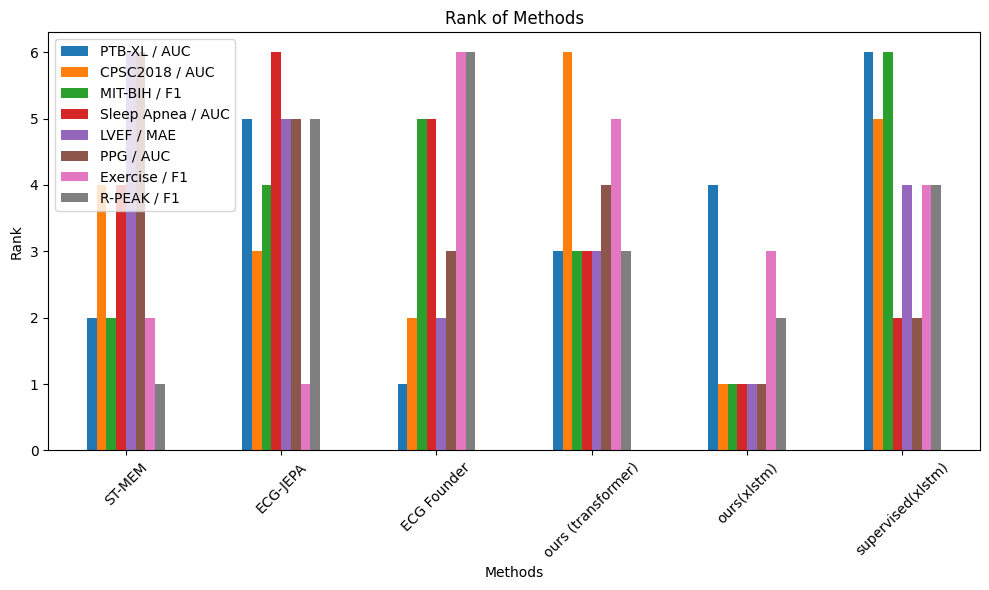

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
df_ranked.plot(kind='bar', ax=ax, legend=False)
plt.xticks(rotation=45)
ax.set_xticklabels(methods, rotation=45)
plt.xlabel('Methods')
plt.ylabel('Rank')
plt.title('Rank of Methods')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_1036350/2596381787.py:12: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



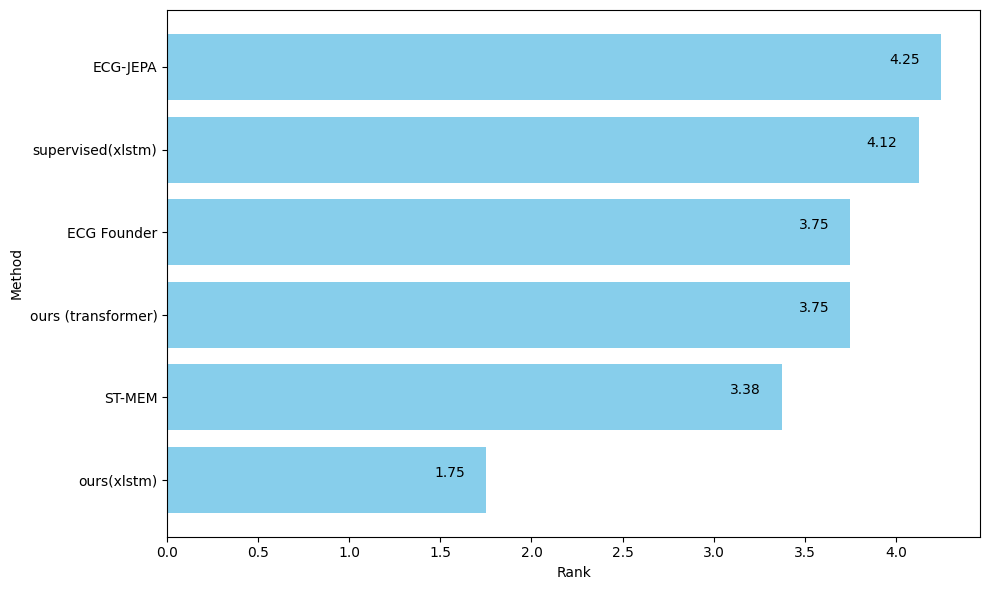

In [12]:
import matplotlib.pyplot as plt
df_ranked_sorted = df_ranked.copy()
df_ranked_sorted["mean_rank"] = df_ranked.mean(axis=1)
df_ranked_sorted = df_ranked_sorted.sort_values(by="mean_rank", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
# horizontal bar plot
ax.barh(df_ranked_sorted.index, df_ranked_sorted["mean_rank"], color='skyblue')
# add label to each bar
for i, v in enumerate(df_ranked_sorted["mean_rank"]):
    ax.text(v - 0.2, i, str(round(v, 2)), ha='center', va='bottom')
ax.set_yticklabels(df_ranked_sorted.index)
plt.xlabel('Rank')
plt.ylabel('Method')
plt.tight_layout()
plt.show()

['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A', '#19D3F3']


/tmp/ipykernel_1036350/4038240990.py:32: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_1036350/4038240990.py:33: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



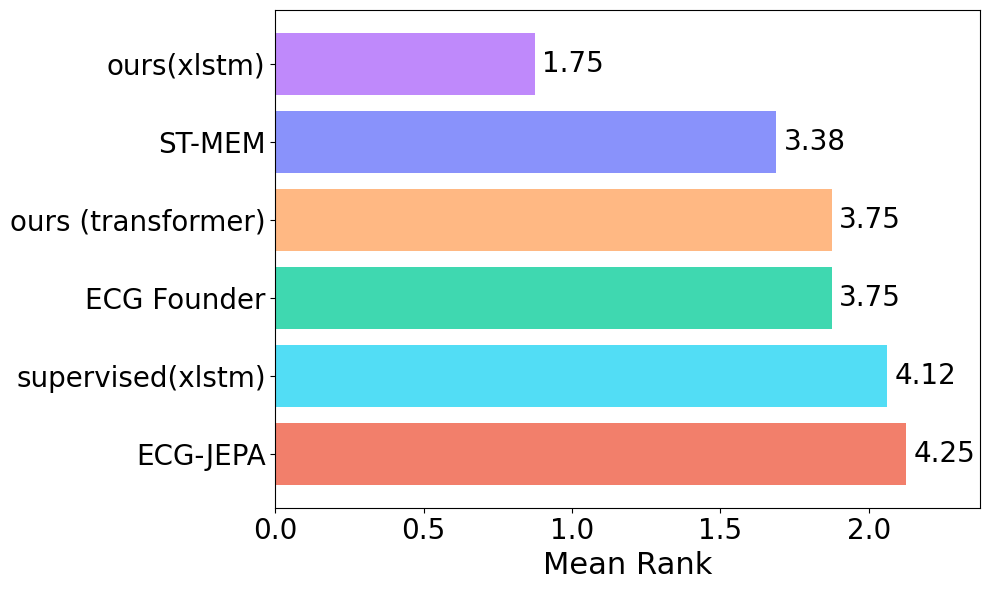

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from plotly.colors import qualitative
from matplotlib.ticker import MultipleLocator

# Prepare data
df_ranked_sorted = df_ranked.copy()
df_ranked_sorted["mean_rank"] = df_ranked.mean(axis=1)
df_ranked_sorted = df_ranked_sorted.sort_values(by="mean_rank", ascending=True)

# Set style
# sns.set(style="whitegrid")

pastel_colors = qualitative.Plotly[:len(df_ranked_sorted)]
# convert to hex
print(pastel_colors)
# change indexes 
pastel_colors = [pastel_colors[i] for i in [3, 0, 4, 2, 5, 1]]
# add some alpha for better visibility
pastel_colors = [f"{color}c0" for color in pastel_colors]  #

# Generate color gradient
norm = plt.Normalize(df_ranked_sorted["mean_rank"].min(), df_ranked_sorted["mean_rank"].max())
colors = pastel_colors

fig, ax = plt.subplots(figsize=(10, 6))

# Draw horizontal bars
bars = ax.barh(df_ranked_sorted.index, df_ranked_sorted["mean_rank"], color=colors)
ax.set_yticklabels(df_ranked_sorted.index, fontsize=20)
ax.set_xticklabels(ax.get_xticks(), fontsize=20)

# Add labels to bars
for i, (value, label) in enumerate(zip(df_ranked_sorted["mean_rank"], df_ranked_sorted.index)):
    ax.text(value + 0.05, i, f"{value:.2f}", va='center', ha='left', fontsize=20, color='black')

# Format plot
ax.set_xlabel('Mean Rank', fontsize=22)
#ax.set_ylabel('Method', fontsize=12)
# ax.set_title('Mean Rank of Methods', fontsize=14, weight='bold', pad=15)
ax.invert_yaxis()  # Highest rank at top
ax.set_xlim([0, df_ranked_sorted["mean_rank"].max() + 0.5])  # Adjust x-axis limit
ax.xaxis.set_minor_locator(MultipleLocator(250))

# ax.grid(True, axis='x', linestyle='--', alpha=0.7)
# ax.set_axisbelow(True)

# Remove spines
# sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig("mean_rank_methods.png", dpi=300)


In [14]:
df_ranked_r = len(df_ranked) - df_ranked
df_ranked_r.head()

,PTB-XL / AUC,CPSC2018 / AUC,MIT-BIH / F1,Sleep Apnea / AUC,LVEF / MAE,PPG / AUC,Exercise / F1,R-PEAK / F1
ST-MEM,4.0,2.0,4.0,2.0,0.0,0.0,4.0,5.0
ECG-JEPA,1.0,3.0,2.0,0.0,1.0,1.0,5.0,1.0
ECG Founder,5.0,4.0,1.0,1.0,4.0,3.0,0.0,0.0
ours (transformer),3.0,0.0,3.0,3.0,3.0,2.0,1.0,3.0
ours(xlstm),2.0,5.0,5.0,5.0,5.0,5.0,3.0,4.0


In [15]:

categories_closed = categories + [categories[0]]

fig = go.Figure()

for idx, row in df_ranked_r.iterrows():
    values = row.tolist() + [row.tolist()[0]]  # close the loop
    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=categories_closed,
        fill='toself',
        name=idx,
        line=dict(width=2)
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=False, range=[-1, 4])
    ),
    showlegend=True,
    title="Rank Radar Chart"
)

fig.show()